# Projeto Ir Além – Transfer Learning e Fine Tuning  
### Fase 6 – Capítulo 1 | FIAP  

## Integrantes
- Leticia Angelim Guerra (RM 567501)  
- Rivando Bezerra Cavalcanti Neto (RM 568235)  
- Tales Ferraz de Arruda Domienikan (RM 567483)  
- Matheus Guimarães França (RM 567144)  
- João Rafael Gonçalves Ramos (RM 567908)  

---

## Descrição
Este notebook contém a implementação prática do projeto **Ir Além – Opção 3.2**, com foco em **Transfer Learning, Fine Tuning e segmentação de imagens**.

## Objetivos
- Aplicar Transfer Learning com MobileNetV2  
- Realizar Fine Tuning das camadas finais  
- Testar segmentação de imagens (remoção de fundo)  
- Comparar desempenho entre imagens originais e segmentadas  

## Abordagens avaliadas
- Classificação com Transfer Learning (imagens originais)  
- Classificação com Transfer Learning (imagens segmentadas)  

## Conexão com Google Drive
Nesta etapa, o Google Drive é montado para acesso ao dataset.
O dataset deve estar em `MyDrive/dataset-classificacao/` com subpastas `train`, `val` e `test`, cada uma contendo as classes `cow` e `dog`.


In [51]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
import os
# Caminho base do dataset
base_path = "/content/drive/MyDrive/dataset-classificacao"
os.listdir(base_path)

['.DS_Store', 'test', 'val', 'train']

## Preparação dos Dados

Nesta etapa, as imagens são carregadas e pré-processadas utilizando o ImageDataGenerator, aplicando normalização e organizando os dados em conjuntos de treino e validação.

In [53]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define tamanho das imagens e tamanho do batch
img_size = (224, 224)
batch_size = 8

# Define diretórios de treino, validação e teste
train_dir = base_path + "/train"
val_dir = base_path + "/val"
test_dir = base_path + "/test"

# Normalização das imagens
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

# Carrega imagens de treino
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

# Carrega imagens de validação
val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

Found 64 images belonging to 2 classes.
Found 8 images belonging to 2 classes.


## Construção do Modelo (Transfer Learning)

Nesta etapa, foi utilizada a arquitetura MobileNetV2 pré-treinada no ImageNet como base para o modelo. A estratégia adotada consiste em utilizar a rede como extratora de características, mantendo suas camadas congeladas, e adicionar uma camada final de classificação para o problema proposto.

In [54]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Carrega modelo pré-treinado na ImageNet (sem a camada final)
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Congela as camadas da rede base (Transfer Learning)
base_model.trainable = False

# Cria modelo adicionando camadas de classificação
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid')
])

# Compila o modelo
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Exibe estrutura do modelo
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Treinamento do Modelo

Nesta etapa, o modelo é treinado utilizando os dados de treino e validado com o conjunto de validação. O objetivo é ajustar os pesos da camada final de classificação, enquanto a rede base permanece congelada.

In [55]:
import time

inicio = time.time()

# Treinamento do modelo com validação
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

tempo_treino = time.time() - inicio

print(f"Tempo de treinamento: {tempo_treino:.2f} segundos")

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.5781 - loss: 0.6712 - val_accuracy: 0.8750 - val_loss: 0.5854
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 359ms/step - accuracy: 0.8281 - loss: 0.4414 - val_accuracy: 0.8750 - val_loss: 0.4271
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 350ms/step - accuracy: 0.9219 - loss: 0.3212 - val_accuracy: 1.0000 - val_loss: 0.3281
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 486ms/step - accuracy: 0.9531 - loss: 0.2392 - val_accuracy: 1.0000 - val_loss: 0.2733
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 457ms/step - accuracy: 0.9531 - loss: 0.1913 - val_accuracy: 1.0000 - val_loss: 0.2405
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 360ms/step - accuracy: 0.9844 - loss: 0.1535 - val_accuracy: 1.0000 - val_loss: 0.2172
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 350ms/step - accuracy: 1.0000 - loss: 0.1325 - val_accuracy: 1.0000 - val_loss: 0.2067
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 371ms/step - accuracy: 1.0000 - loss: 0.1103 - val_accuracy: 1.0000 - val_loss: 0

## Fine Tuning do Modelo

Após o treinamento inicial, foi aplicado o Fine Tuning, que consiste em descongelar parcialmente as camadas finais da rede pré-treinada. Essa estratégia permite ajustar representações mais específicas do problema, mantendo o conhecimento previamente aprendido.

Foi utilizada uma taxa de aprendizado menor (1e-5), com o objetivo de evitar alterações bruscas nos pesos já treinados na ImageNet..

In [56]:
# Fine Tuning: descongelamento parcial da MobileNetV2

base_model.trainable = True

# Mantém a maior parte da rede congelada e libera apenas as últimas camadas
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompila com taxa de aprendizado menor para evitar alterações bruscas nos pesos pré-treinados
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

inicio_finetuning = time.time()

history_finetuning = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

tempo_finetuning = time.time() - inicio_finetuning

print(f"Tempo de Fine Tuning: {tempo_finetuning:.2f} segundos")

Epoch 1/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 684ms/step - accuracy: 0.8906 - loss: 0.2540 - val_accuracy: 1.0000 - val_loss: 0.1596
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 441ms/step - accuracy: 0.8906 - loss: 0.2858 - val_accuracy: 1.0000 - val_loss: 0.1519
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 657ms/step - accuracy: 0.9688 - loss: 0.1852 - val_accuracy: 1.0000 - val_loss: 0.1439
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 454ms/step - accuracy: 0.9375 - loss: 0.1779 - val_accuracy: 1.0000 - val_loss: 0.1366
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 442ms/step - accuracy: 0.9062 - loss: 0.2450 - val_accuracy: 1.0000 - val_loss: 0.1299
Tempo de Fine Tuning: 32.38 segundos


## Avaliação do Modelo

Após o treinamento e o Fine Tuning, o modelo é avaliado utilizando o conjunto de teste, com o objetivo de medir sua capacidade de generalização em dados não vistos.

In [57]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Carrega imagens de teste
test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

# Avaliação do modelo no conjunto de teste
test_loss, test_acc = model.evaluate(test_data)
print(f"Acurácia no teste: {test_acc:.4f}")

Found 8 images belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 1.0000 - loss: 0.0738
Acurácia no teste: 1.0000


In [58]:
# Instala biblioteca para remoção de fundo (segmentação)
!pip install "rembg[cpu]" onnxruntime -q

## Segmentação das Imagens (Remoção de Fundo)

Nesta etapa, foi aplicada uma técnica de segmentação automática utilizando a biblioteca rembg, com o objetivo de remover o fundo das imagens e manter apenas o objeto de interesse.

O processo foi realizado de forma automatizada para todos os conjuntos (treino, validação e teste), criando um novo dataset com as imagens pré-processadas.

In [59]:
# Importa bibliotecas para segmentação de imagens
from rembg import remove
from PIL import Image
import os

# Define caminhos de entrada (original) e saída (sem fundo)
input_base = base_path
output_base = "/content/drive/MyDrive/dataset_sem_fundo"

# Percorre os conjuntos de treino, validação e teste
for split in ["train", "val", "test"]:
    for classe in ["cow", "dog"]:

        input_dir = os.path.join(input_base, split, classe)
        output_dir = os.path.join(output_base, split, classe)

        # Cria diretório de saída, se não existir
        os.makedirs(output_dir, exist_ok=True)

        # Processa cada imagem
        for file in os.listdir(input_dir):
            if file.endswith(".jpg"):
                input_path = os.path.join(input_dir, file)
                output_path = os.path.join(output_dir, file)

                # Abre imagem e remove o fundo
                image = Image.open(input_path)
                output = remove(image)

                # Conversão para RGB, pois imagens JPEG não aceitam transparência
                output = output.convert("RGB")

                # Salva imagem processada
                output.save(output_path)

print("Remoção de fundo concluída!")

Remoção de fundo concluída!


## Visualização do Processo de Segmentação

Conforme requisito do enunciado, abaixo é demonstrado o processo completo de segmentação para imagens de cada classe: **(1)** imagem original, **(2)** máscara binária obtida pela rede U²-Net via `rembg`, e **(3)** imagem original com o background recortado pela aplicação da máscara sobre os pixels.

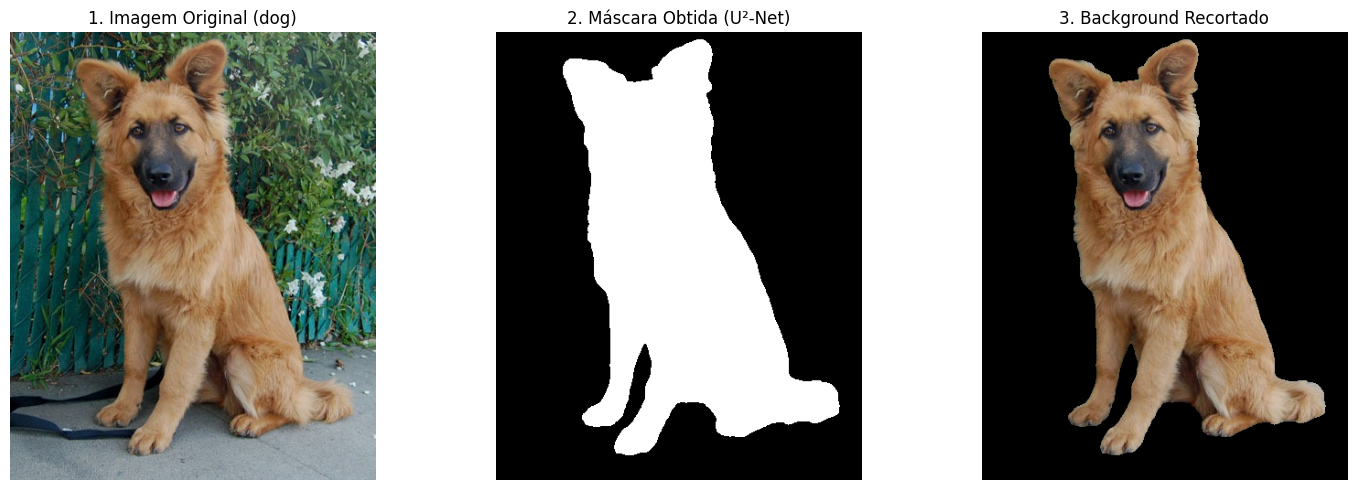

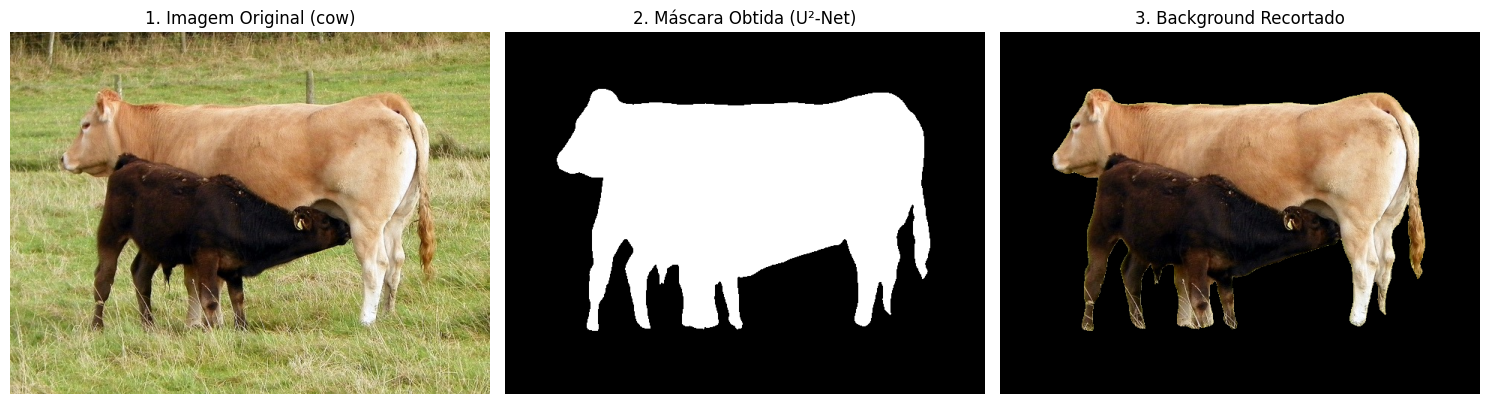

In [61]:
from rembg import remove
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Função que retorna original, máscara binária e imagem recortada
def gerar_mascara(img_path):
    img_original = Image.open(img_path).convert("RGB")
    img_sem_fundo = remove(img_original)  # retorna RGBA

    # Canal alpha contém a máscara
    mascara = np.array(img_sem_fundo)[:, :, 3]
    mascara_bin = (mascara > 128).astype(np.uint8) * 255

    # Aplica a máscara sobre a imagem original (fundo preto)
    img_array = np.array(img_original)
    img_recortada = img_array.copy()
    img_recortada[mascara_bin == 0] = 0

    return img_original, mascara_bin, img_recortada

# Demonstração para uma imagem de cada classe
exemplos = [("dog_016.jpg", "dog"), ("cow_018.jpg", "cow")]

for img_name, classe in exemplos:
    img_path = os.path.join(train_dir, classe, img_name)
    original, mascara, recortada = gerar_mascara(img_path)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(original)
    axes[0].set_title(f"1. Imagem Original ({classe})")
    axes[0].axis("off")

    axes[1].imshow(mascara, cmap="gray")
    axes[1].set_title("2. Máscara Obtida (U²-Net)")
    axes[1].axis("off")

    axes[2].imshow(recortada)
    axes[2].set_title("3. Background Recortado")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

## Carregamento do Dataset Sem Fundo

Nesta etapa, o novo dataset gerado após a remoção de fundo é carregado para o treinamento do modelo.

Assim como na abordagem anterior, é aplicado o pré-processamento com normalização dos pixels e organização dos dados em conjuntos de treino e validação, permitindo a comparação entre as imagens originais e as imagens segmentadas.

In [60]:
# Importa gerador de imagens
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Caminho do novo dataset (sem fundo)
new_base = "/content/drive/MyDrive/dataset_sem_fundo"

# Define diretórios de treino, validação e teste
train_dir2 = new_base + "/train"
val_dir2 = new_base + "/val"
test_dir2 = new_base + "/test"

# Carrega dados de treino com normalização
train_data2 = ImageDataGenerator(rescale=1./255).flow_from_directory(
    train_dir2,
    target_size=(224,224),
    batch_size=8,
    class_mode='binary'
)

# Carrega dados de validação
val_data2 = ImageDataGenerator(rescale=1./255).flow_from_directory(
    val_dir2,
    target_size=(224,224),
    batch_size=8,
    class_mode='binary'
)

Found 64 images belonging to 2 classes.
Found 8 images belonging to 2 classes.


## Construção e Treinamento do Modelo com Imagens Sem Fundo

Nesta etapa, é construído um novo modelo utilizando Transfer Learning com a arquitetura MobileNetV2, aplicado ao dataset sem fundo gerado anteriormente.

Assim como na primeira abordagem, a rede pré-treinada na ImageNet é utilizada como extratora de características, mantendo suas camadas congeladas e treinando apenas a camada final de classificação.

O objetivo desta etapa é avaliar se a remoção do fundo das imagens contribui para a melhoria do desempenho do modelo, facilitando a identificação dos objetos de interesse.

In [47]:
# Importa modelo pré-treinado e camadas
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Carrega MobileNetV2 pré-treinada (sem camada final)
base_model2 = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Congela as camadas da rede base
base_model2.trainable = False

# Cria modelo adicionando camada de classificação
model2 = models.Sequential([
    base_model2,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid')
])

# Compila o modelo
model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Treina o modelo com imagens sem fundo
history2 = model2.fit(
    train_data2,
    validation_data=val_data2,
    epochs=10
)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 572ms/step - accuracy: 0.6250 - loss: 0.6811 - val_accuracy: 0.5000 - val_loss: 0.5957
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 339ms/step - accuracy: 0.7344 - loss: 0.5185 - val_accuracy: 0.8750 - val_loss: 0.4095
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 359ms/step - accuracy: 0.8906 - loss: 0.3599 - val_accuracy: 0.8750 - val_loss: 0.3303
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 329ms/step - accuracy: 0.9219 - loss: 0.2935 - val_accuracy: 0.8750 - val_loss: 0.2818
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 325ms/step - accuracy: 0.9219 - loss: 0.2371 - val_accuracy: 0.8750 - val_loss: 0.2635
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 580ms/step - accuracy: 0.9688 - loss: 0.1922 - val_accuracy: 0.8750 - val_loss: 0.2241
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 334ms/step - accuracy: 0.9688 - loss: 0.1595 - val_accuracy: 0.8750 - val_loss: 0.2033
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 385ms/step - accuracy: 1.0000 - loss: 0.1349 - val_accuracy: 0.8750 - val_loss

## Avaliação do Modelo com Imagens Sem Fundo

Nesta etapa, o modelo treinado com as imagens segmentadas é avaliado no conjunto de teste. O objetivo é comparar seu desempenho com o modelo treinado usando as imagens originais.

In [48]:
# Avaliação do modelo treinado com imagens sem fundo
test_data2 = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir2,
    target_size=(224,224),
    batch_size=8,
    class_mode='binary'
)

test_loss2, test_acc2 = model2.evaluate(test_data2)

print(f"Acurácia no teste com imagens sem fundo: {test_acc2:.4f}")

Found 8 images belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 1.0000 - loss: 0.1513
Acurácia no teste com imagens sem fundo: 1.0000


## 📊 Análise dos Resultados

Neste projeto, foi utilizada a técnica de Transfer Learning com a arquitetura MobileNetV2, previamente treinada no ImageNet. Inicialmente, a rede foi utilizada como extratora de características, mantendo suas camadas congeladas e treinando apenas a camada final de classificação para diferenciar as classes (cow e dog).

O modelo treinado com as imagens originais apresentou ótimo desempenho ao longo do treinamento, atingindo **100% de acurácia no conjunto de teste**, tanto na fase inicial quanto após o Fine Tuning.

Em seguida, foi aplicada a remoção de fundo das imagens utilizando a biblioteca rembg, com o objetivo de destacar apenas o objeto principal. Após o treinamento com esse novo conjunto de dados, os resultados foram:

- Acurácia de validação: **100%**
- Acurácia de teste: **87,5%**

Comparando os dois cenários, a remoção do fundo **não trouxe ganhos — pelo contrário, reduziu a acurácia no conjunto de teste de 100% para 87,5%**. Isso indica que o modelo original já conseguia identificar bem os objetos mesmo com elementos de fundo presentes, e que a etapa de segmentação pode ter removido informações de contexto que ajudavam na classificação (ex.: ambiente típico de cada animal).

Outro fator importante é o tamanho reduzido do dataset, principalmente no conjunto de teste (apenas 8 imagens). Isso faz com que cada erro represente uma queda de 12,5% na acurácia, o que limita a confiabilidade da comparação.

Além disso, foi aplicada uma etapa de Fine Tuning, com o descongelamento parcial das últimas 20 camadas da rede e uso de uma taxa de aprendizado menor (1e-5). Essa etapa permitiu ajustar melhor o modelo ao problema, sem alterar de forma brusca os pesos aprendidos anteriormente.

## Conclusão

O uso de Transfer Learning com a MobileNetV2 se mostrou eficiente para o problema proposto, permitindo alcançar 100% de acurácia mesmo com uma quantidade limitada de dados (apenas 80 imagens).

O Fine Tuning manteve a acurácia no patamar máximo, indicando que o modelo já estava bem ajustado mesmo antes do descongelamento parcial das camadas.

Já a remoção de fundo, apesar de ser uma técnica interessante de pré-processamento, **piorou o desempenho** neste cenário (queda de 100% para 87,5% no teste). Isso sugere que o contexto presente no fundo das imagens contribuía para a classificação correta — algo coerente com o fato da MobileNetV2 ter sido treinada na ImageNet, onde animais aparecem em seus ambientes naturais.

Por fim, é importante destacar que o tamanho reduzido do dataset limita a análise dos resultados. Em cenários com mais dados, os efeitos do pré-processamento e do Fine Tuning poderiam ser avaliados de forma mais confiável.

## Comparação Visual das Imagens


A seguir, são apresentados exemplos de imagens originais e suas respectivas versões após a remoção de fundo, evidenciando o efeito da segmentação aplicada no projeto.

No primeiro exemplo (cachorro), há um cenário mais simples, com apenas um objeto principal bem definido. Nesse caso, a remoção do fundo foi bastante precisa, mantendo apenas o animal e eliminando corretamente o restante da imagem.

Já no segundo exemplo (vaca), o cenário é mais complexo, com mais de um objeto em primeiro plano. Nesse caso, a segmentação manteve tanto a vaca quanto o bezerro, mostrando que a técnica utilizada não distingue entre diferentes objetos, mas sim separa o que está em destaque do fundo.

Isso evidencia uma limitação da abordagem utilizada, que não possui entendimento das classes presentes na imagem, realizando apenas a separação entre primeiro plano e fundo.

Mesmo assim, a técnica se mostrou útil para reduzir ruídos visuais, simplificando as imagens. Em alguns casos, isso pode contribuir para o desempenho de modelos de classificação, especialmente quando o fundo interfere na identificação do objeto.

Por fim, vale destacar que, em cenários mais complexos, técnicas mais avançadas — como detecção de objetos ou segmentação semântica — seriam mais adequadas quando o objetivo é isolar apenas um objeto específico.

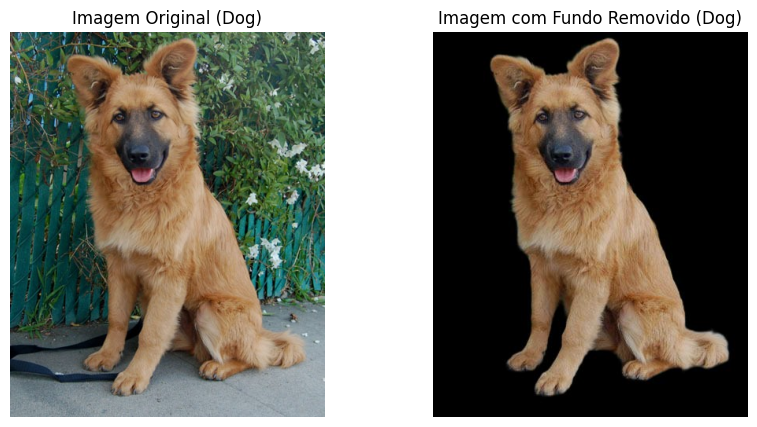

In [49]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Exemplo de comparação: imagem original vs imagem sem fundo (cachorro)
# imagem escolhida (cachorro)
img_name = "dog_016.jpg"

# caminhos
original_path = os.path.join(train_dir, "dog", img_name)
sem_fundo_path = os.path.join("/content/drive/MyDrive/dataset_sem_fundo/train/dog", img_name)

# abrir imagens
original = Image.open(original_path)
sem_fundo = Image.open(sem_fundo_path)

# plot
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Imagem Original (Dog)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(sem_fundo)
plt.title("Imagem com Fundo Removido (Dog)")
plt.axis("off")

plt.show()

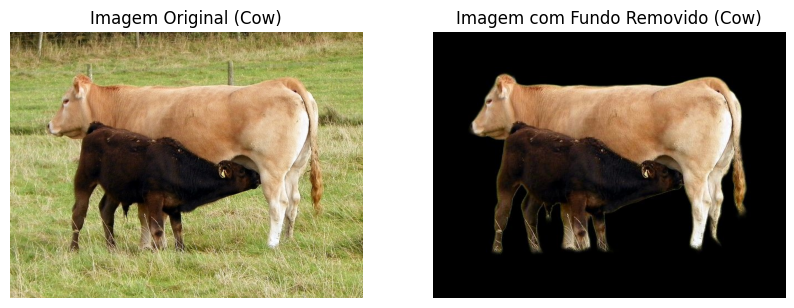

In [50]:

# Exemplo de comparação: imagem original vs imagem sem fundo (vaca)
# imagem escolhida (vaca)
img_name = "cow_018.jpg"

# caminhos
original_path = os.path.join(train_dir, "cow", img_name)
sem_fundo_path = os.path.join("/content/drive/MyDrive/dataset_sem_fundo/train/cow", img_name)

# abrir imagens
original = Image.open(original_path)
sem_fundo = Image.open(sem_fundo_path)

# plot
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Imagem Original (Cow)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(sem_fundo)
plt.title("Imagem com Fundo Removido (Cow)")
plt.axis("off")

plt.show()